In [92]:
%load_ext autoreload
%autoreload 2
import numpy as np
import matplotlib.pyplot as plt
from coffea import util
from coffea.processor import accumulate
import os
import re
import pandas as pd
import hist
import matplotlib as mpl
import mplhep
import sys
import hist
import hist.intervals

sys.path.append("../analysisTools/")
import plotTools as ptools
import utils

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [93]:
f_sig = "../coffea/AllInOne_2022/Resolution_DSCBsigma.coffea"

sig_histo = util.load(f_sig) [0]


Hist(
  Variable(array([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12.,
       13., 14., 15., 16., 17., 18., 19., 20., 21., 22., 23., 24., 25.]), name='Gen_pt'),
  Regular(200, -1, 1, name='Res_GED'),
  storage=Weight()) # Sum: WeightedSum(value=159, variance=159) (WeightedSum(value=166, variance=166) with flow)
<class 'hist.hist.Hist'>


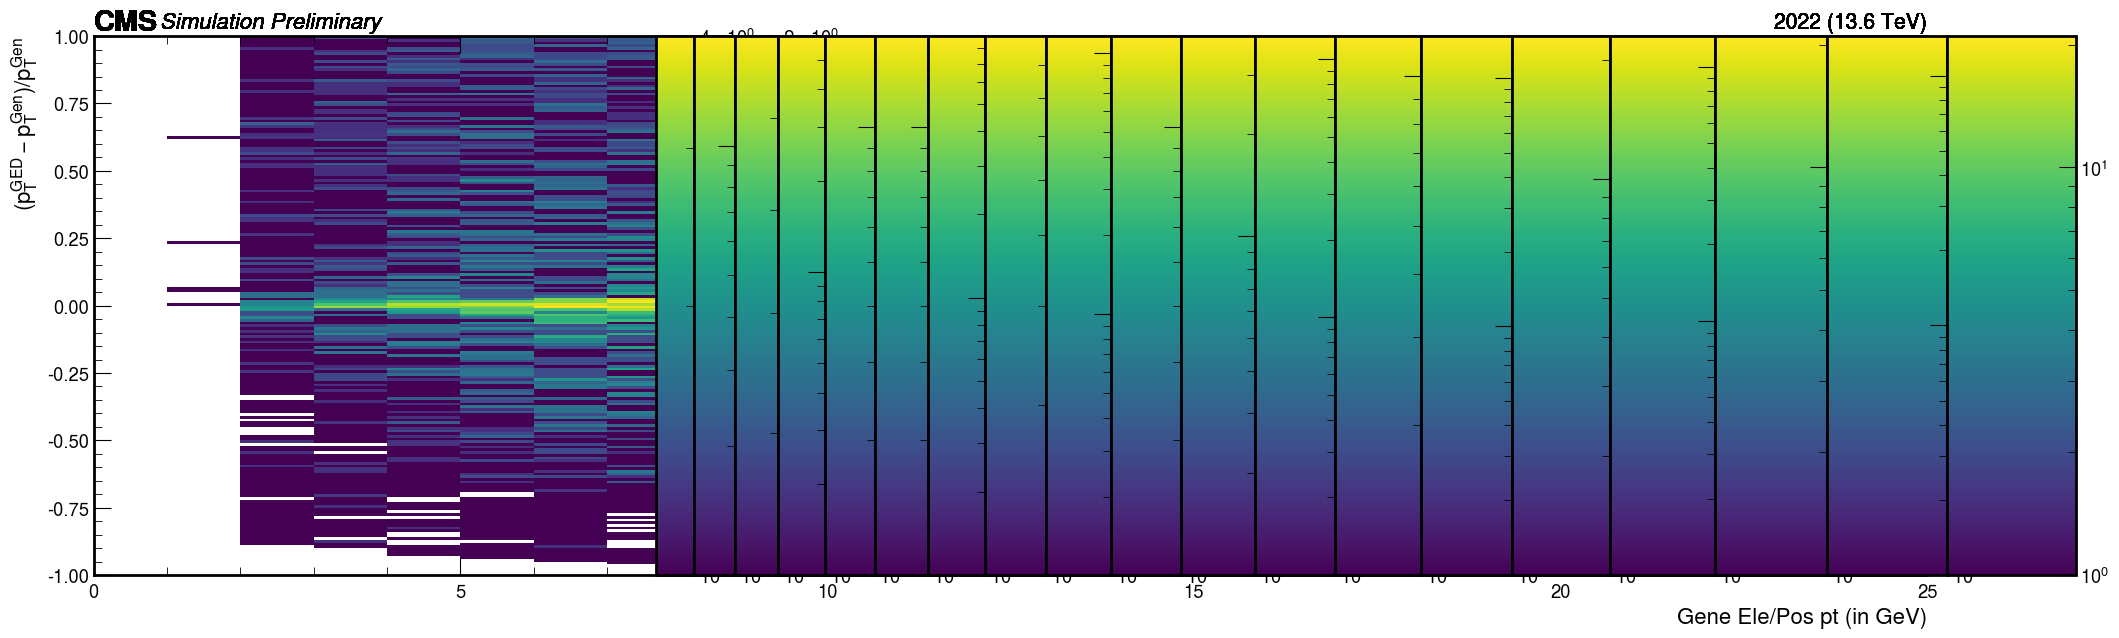

In [94]:
fig, ax = plt.subplots(figsize=(7,7))


# Plot settings
plot_dict = {
    'variable':'res_GED_gen_ptbin',
    'cut': 'cut1',
    'year': 2022
}


style_2d_dict = {
    'fig': fig,
    'ax': ax,
    'xrebin': None,
    'yrebin': None,
    'xlim': None,     # if None, the default will show up; otherwise give as a list, i.e. [0, 10]  
    'ylim': None,     # if None, the default will show up; otherwise give as a list, i.e. [0, 10]
    'doLogy': False, 
    'doLogx': False,
    'doLogz': True,
    'xlabel': "Gene Ele/Pos pt (in GeV)",   # if None, the default will show up; otherwise give as a string, i.e. 'Electron dxy'
    'ylabel': r'$(p_{T}^{\mathrm{GED}}-p_{T}^{\mathrm{Gen}})/p_{T}^{\mathrm{Gen}}$',   # if None, the default will show up; otherwise give as a string, i.e. 'Efficiency'
    'zlabel': None,   
    'flow': None,     # overflow
    'doSave': False,
    'outDir': './plots/signal_2018',
    'outName': f'ptvslxy.png'
}

#signal points
samples = {
    10: 
    {
        0.1: [10],
        0.2: [1,100],
    },
    20: 
    {
        
        0.2: [1, 100],
    },
    30: 
    {
        0.1: [10],
        0.2: [1,100]
    },
    40: 
    {
        0.2: [1, 100],
    },
    50:
    {
        0.1: [10],
        0.2: [1,100],
    },
    60:
    {
         0.2: [1,100],
    },
    70:
    {
         0.2: [1,100],
    },
    80:
    {
         0.2: [1,100],
    }
 
}


h_list_lpt=[]
h_sum_lpt = None

for m1,deltas in samples.items():
    for delta, ctaus in deltas.items():
        for ctau in ctaus:
            h_lpt = ptools.plot_signal_2D(sig_histo, m1, delta, ctau, plot_dict, style_2d_dict)
            h_list_lpt.append(h_lpt)            
            if h_sum_lpt is None:
                h_sum_lpt = h_lpt.copy()
                print (h_sum_lpt)
            else:
                h_sum_lpt += h_lpt



/uscms/home/reshmar/nobackup/miniforge3/envs/coffea/lib/python3.8/site-packages/mplhep/utils.py:199: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values, variances) - self.values)
/uscms/home/reshmar/nobackup/miniforge3/envs/coffea/lib/python3.8/site-packages/mplhep/plot.py:494: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  _e = ax.errorbar(
/uscms/home/reshmar/nobackup/miniforge3/envs/coffea/lib/python3.8/site-packages/mplhep/plot.py:494: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  _e = ax.errorbar(
/uscms/home/reshmar/nobackup/miniforge3/envs/coffea/lib/python3.8/site-packages/mplhep/plot.py:494: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (->

Text(0, 1, 'Entries')

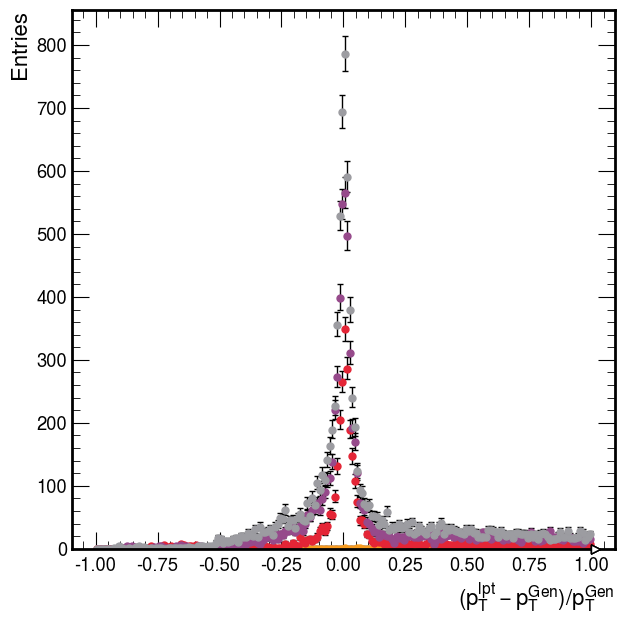

In [95]:
#We need resolution in different bins of pT. We now get the y axis in different slices of x axis.
fig, ax = plt.subplots(figsize=(7,7))

COUNTS = [] #Gives Counts per slice. You have 3 slices. So you will get 3 lists inside COUNTS. 
EDGES = []
BINSX =[]
VARIANCES = []
YERR = []

for i in range (0,5):
    mplhep.histplot(h_sum_lpt[i,:], histtype='errorbar',yerr=True, fmt='o', capsize=2, ecolor='black')
    
    counts_lpt = h_sum_lpt[i,:].values()
    COUNTS.append(counts_lpt) 
    
    variances_lpt = h_sum_lpt[i,:].variances()
    VARIANCES.append(variances_lpt)
    
    yerr_lpt = np.sqrt(variances_lpt)
    YERR.append(yerr_lpt)

    edges_lpt = h_sum_lpt[i,:].axes[0].edges
    EDGES.append(edges_lpt)   

    bin_x_lpt = (edges_lpt[1:]+edges_lpt[:-1])/2
    BINSX.append(bin_x_lpt)
    
    

plt.xlabel(r'$(p_{T}^{\mathrm{lpt}}-p_{T}^{\mathrm{Gen}})/p_{T}^{\mathrm{Gen}}$')
plt.ylabel("Entries")



In [96]:
#1. Define your model

def double_cb(x,u,sig, nl, a_l, nr, a_r,N):
    t=(x-u)/(sig)
    al = abs(a_l)
    ar = abs(a_r)

    left_tail = t < -al
    core = (t>-al) & (t<ar)
    right_tail = t > ar

    y=np.empty_like(t)

    y[core] = np.exp(-0.5*t[core]*t[core])

    A_L = (nl / al)**nl * np.exp(-0.5 * al**2)
    B_L = (nl / al) - al
    y[left_tail] = A_L / (B_L - t[left_tail])**nl

    A_R = (nr / ar)**nr * np.exp(-0.5 * ar**2)
    B_R = (nr / ar) - ar
    y[right_tail] = A_R / (B_R + t[right_tail])**nr

    return N*y


In [99]:
xdata = BINSX
ydata = COUNTS
yerror = YERR

xyz = [[x, y, z] for x, y, z in zip(xdata, ydata, yerror)]

ydata_new =[]
xdata_new = []
yerror_new = []

for i,j, k in xyz:
    mask = j>0
    ydata_new.append(j[mask])
    xdata_new.append(i[mask])
    yerror_new.append(k[mask])

#You now have xdata, ydata, yerr with elements all greater than 0.

[array([], dtype=float64), array([1., 1., 1., 1., 1.]), array([  1.,   1.,   2.,   1.,   1.,   1.,   1.,   2.,   1.,   1.,   2.,
         4.,   1.,   2.,   1.,   1.,   6.,   3.,   4.,   1.,   1.,   1.,
         7.,   6.,   3.,   4.,   5.,   2.,   6.,   1.,   3.,   3.,   3.,
         2.,   1.,   1.,   2.,   2.,   2.,   1.,   1.,   1.,   1.,   1.,
         1.,   2.,   1.,   3.,   4.,   3.,   2.,   3.,   1.,   2.,   2.,
         2.,   8.,   4.,   3.,  10.,   6.,   5.,  18.,  11.,  10.,  14.,
        16.,  12.,  15.,  19.,  29.,  34.,  28.,  36.,  56.,  54.,  83.,
       131., 205., 265., 349., 286., 189., 147., 107.,  75.,  45.,  45.,
        39.,  23.,  22.,  13.,  10.,  13.,  11.,  11.,   8.,  11.,   7.,
         8.,   6.,   7.,   7.,   8.,   7.,   9.,   4.,   8.,   9.,   8.,
         7.,   6.,   5.,   7.,  11.,  11.,   2.,   7.,   9.,   4.,   2.,
         7.,   6.,   6.,   6.,  15.,   4.,   7.,   5.,  10.,   6.,   9.,
         5.,   9.,  11.,   4.,   5.,   9.,   3.,   7.,  11.,   2.,  

In [101]:
from scipy.optimize import curve_fit

xyz = [
    (x, y, yerr)
    for x, y, yerr in zip(xdata_new, ydata_new, yerror_new)
    if len(x) >7
]

for i, (x, y, yerr) in enumerate(xyz): 
    print (x)
    mplhep.histplot( h_sum_lpt[i, :],histtype='errorbar', yerr=True,  fmt='o',capsize=2, ecolor='black', label='Histogram'     )

    # popt, pcov = curve_fit(
    #     double_cb,
    #     x,
    #     y
        
    # )
    # print ("popt=", popt)
    # print ("pcov=", pcov)



# for array,element in enumerate(xdata_new):
#     print (array)
#     print (element)
#     mplhep.histplot(h_sum_lpt[array,:], histtype='errorbar',yerr=True, fmt='o', capsize=2, ecolor='black', label='Histogram')
#     popt, pcov = curve_fit(double_cb, element, ydata_new[j])


# initial_guess = [0.0002642, 0.02177, 1, 0.2, 1, 0.2,200] #[mean, sigma, nl, al, nr, ar, N]

# XYZ = [[X, Y, Z] for X, Y, Z in zip(xdata_new, ydata_new, yerror_new)]

# print (XYZ)

# for i,j,k in XYZ:
#     print (XYZ[i])
    # popt, pcov = curve_fit(double_cb, xdata_new[i], ydata_new[j], p0=initial_guess, sigma=yerror_new[k], absolute_sigma=True)

[-0.885 -0.875 -0.865 -0.855 -0.845 -0.835 -0.825 -0.815 -0.805 -0.795
 -0.785 -0.775 -0.765 -0.755 -0.745 -0.735 -0.725 -0.705 -0.695 -0.685
 -0.675 -0.665 -0.655 -0.645 -0.635 -0.625 -0.615 -0.605 -0.595 -0.585
 -0.575 -0.565 -0.555 -0.545 -0.535 -0.525 -0.505 -0.495 -0.485 -0.445
 -0.435 -0.415 -0.395 -0.385 -0.375 -0.365 -0.355 -0.325 -0.315 -0.305
 -0.295 -0.285 -0.275 -0.265 -0.255 -0.245 -0.235 -0.225 -0.215 -0.205
 -0.195 -0.185 -0.175 -0.165 -0.155 -0.145 -0.135 -0.125 -0.115 -0.105
 -0.095 -0.085 -0.075 -0.065 -0.055 -0.045 -0.035 -0.025 -0.015 -0.005
  0.005  0.015  0.025  0.035  0.045  0.055  0.065  0.075  0.085  0.095
  0.105  0.115  0.125  0.135  0.145  0.155  0.165  0.175  0.185  0.195
  0.205  0.215  0.225  0.235  0.245  0.255  0.265  0.275  0.285  0.295
  0.305  0.315  0.325  0.335  0.345  0.355  0.365  0.375  0.385  0.395
  0.405  0.415  0.425  0.435  0.445  0.455  0.465  0.475  0.485  0.495
  0.505  0.515  0.525  0.535  0.545  0.555  0.565  0.575  0.585  0.595
  0.60